# DIVACoast.jl - DECIPHER Summer School 2025, Bilbao

## What is DIVACoast.jl? 

`DIVACoast.jl` is a package for the programming language Julia. The package is currently under development and designed to provide a broad toolset for **coastal risk & adapatation assessment**. The key concept of `DIVACoast.jl` is the concept of risk. Following the definition of the Intergovernmental Panel on Climate Change (IPCC), risk constituted by the three components of hazard, exposure and vulnerability (Oppenheimer et al., 2019; Wong et al., 2014). While on the long run the package is meant to serve multiple coastal risks including the risk of flooding, erosion, salinity intrusion and wetland change, the current release concentrates on flood risk.

## What will you learn?

1. Install `DIVACoast.jl` & it's dependencies
2. Exposure assessment using the `HypsometricProfile`
    - using a bathtub model
    - usina an attenuated bathtub model

## Instantiate DIVACoast.jl
`DIVACoast.jl` is currently under development and not registered as an offical Julia Package, hence, you need to install it directly from the ´DIVACoast.jl` repository.

### On GoogleColab

In [ ]:
using Pkg
Pkg.add(url = "https://github.com/GlobalClimateForum/DIVACoast.jl")

### On Local

In [51]:
using Pkg
Pkg.activate("../.")
include("../src/DIVACoast.jl")
using .DIVACoast
using Plots
using DataFrames

  Activating project at `~/DIVA/DIVACoast`
┌ Warning: Replacing docs for `Main.DIVACoast.damage_bathtub_standard_ddf :: Union{Tuple{DT}, Tuple{Main.DIVACoast.HypsometricProfile{DT}, DT, DT, Array{DT}}} where DT<:Real` in module `Main.DIVACoast`
└ @ Base.Docs docs/Docs.jl:243


┌                                       ┐
│ DIVACoast.jl | © GLOBAL CLIMATE FORUM │
└                                       ┘


## Exposure - HypsometricProfiles

Currently the main way to represent exposure in DIVACoast.jl is as `HypsometricProfile`. This is a special kind of coastal profile that allows for a very efficient computation of flood damages, which is beneficial for running large number of damage assessments as, e.g., required for many economic questions that involve optimization.

In [50]:
testdata    = "../testdata/UKIRL/nc/UKIRL_hspfs_floodplains.nc"
hspfs = load_hsps_nc(Int32, Float32, testdata)    |> HypsometricProfileCollection

UndefVarError: UndefVarError: `load_hsps_nc` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

In [6]:
hspfs[22]

┌ HypsometricProfile
├ Width: 2.2332425 km
├ Elevation: -5.0 up to 20.0m at 251 increments
├ Cum. area (maximum): 7.3564367km^2
└ Exposures:
  ├ population: 251 values from 0.0 to 4.6947346
  ├ assets: 251 values from 0.0 to 501273.1

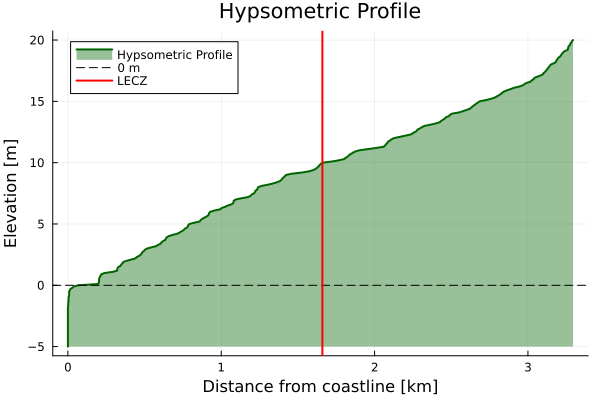

In [8]:
plot(hspfs[22])

In [20]:
df = DataFrame(hspfs[22])
p1 = plot(df[!, :elevation], df[!, :population], xlabel="Elevation [m]", ylabel="Population [people]",
          label="Population", legend=:topleft)
p2 = plot!(twinx(), df[!, :elevation], df[!, :assets], ylabel="Assets [value]", color=:red, label="Assets")
plot(p1, p2, layout=(1,1))

ErrorException: When doing layout, n (1) < n_override (2).  You're probably trying to force existing plots into a layout that doesn't fit them.

## Exposure
- exposure()
- simulate population growth using exposure modifiers
- simulate retreat using exposure modifiers



In [ ]:
exposure(london, 5.0, :population, BathtubInundation())

## Damages
- Calculate Damages using different Inundation Models
- Calculate Damages by sampling from GEV

MethodError: MethodError: no method matching land_raising!(::Main.DIVACoast.HypsometricProfile{Float32}, ::Float64)
The function `land_raising!` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  land_raising!(!Matched::Main.DIVACoast.HypsometricProfile{Float32}, ::DT) where DT<:Real
   @ Main.DIVACoast ~/DIVA/DIVACoast/src/datatypes/hypsometric_profiles/hypsometric_profile_operators.jl:20


ArgumentError: ArgumentError: New columns must have the same length as old columns

In [47]:
ddf = d -> d <= 5 ? d/(d+1) : 1.0
factor = map(ddf, 0:1:10)
plot(0:1:10, factor, xticks=0:1:10, xlabel="Damage Factor", ylabel="Factor", label="Damage Factor",
     title="Damage Factor for GEV Distribution", legend=:topleft)


damage_london = DIVACoast.damage(hspfs[22], 2.0, :assets,  ddf)
damage_london

MethodError: MethodError: no method matching damage(::Main.DIVACoast.HypsometricProfile{Float32}, ::Float64, ::Symbol, ::var"#53#54")
The function `damage` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  damage(!Matched::Main.DIVACoast.LocalCoastalImpactModel{DT, DATA}, ::Real, ::Any, ::Any, !Matched::IM) where {DT<:Real, IM<:Main.DIVACoast.InundationModel, DATA}
   @ Main.DIVACoast ~/DIVA/DIVACoast/src/datatypes/coastal_model/local_coastal_model.jl:119
  damage(!Matched::Main.DIVACoast.LocalCoastalImpactModel{DT, DATA}, ::Real, ::Any, ::Any) where {DT<:Real, DATA}
   @ Main.DIVACoast ~/DIVA/DIVACoast/src/datatypes/coastal_model/local_coastal_model.jl:119
  damage(!Matched::Main.DIVACoast.HypsometricProfile{DT}, ::Real, ::Symbol, ::Function, !Matched::IM) where {DT<:Real, IM<:Main.DIVACoast.InundationModel}
   @ Main.DIVACoast ~/DIVA/DIVACoast/src/datatypes/hypsometric_profiles/hypsometric_profile_damage.jl:36
  ...
